In [ ]:
import pglis
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.dates as mdates

[pglis] SSN updated: 726 points -> /Users/davidpelosi/Desktop/PgLis/pglis/data_products/SSN.csv
[pglis] Dataset is up to date (version https://zenodo.org/records/19971913).


In [ ]:
# init
model = pglis.solar_mod()


# flux vs time
df = pglis.get_flux_vs_time(
    model,
    Z=1,  # H
    Ekn=440.0,  # MeV/n
    t_start=dt.datetime(1996, 1, 1).timestamp(),
    t_end=dt.datetime(2031, 1, 1).timestamp(),
)

df["time_dt"] = pd.to_datetime(df["time_unix"], unit="s")

df2 = pglis.get_flux_vs_time(
    model,
    Z=2,  # He
    Ekn=1000.0,  # MeV/n
    t_start=dt.datetime(1996, 1, 1).timestamp(),
    t_end=dt.datetime(2031, 1, 1).timestamp(),
)


df2["time_dt"] = pd.to_datetime(df2["time_unix"], unit="s")

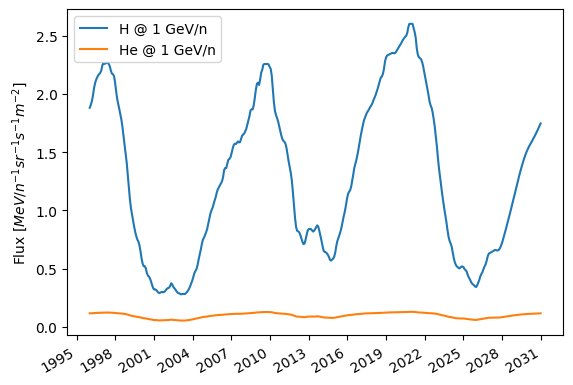

In [ ]:
fig, ax = plt.subplots()

ax.plot(df["time_dt"], df["J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]"], label="H @ 1 GeV/n")
ax.plot(
    df2["time_dt"], df2["J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]"], label="He @ 1 GeV/n"
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

ax.xaxis.set_major_locator(mdates.YearLocator(3))


ax.set_ylabel(r"Flux $[MeV/n^{-1} sr^{-1} s^{-1} m^{-2}]$")
ax.legend()
plt.show()

In [4]:
model = pglis.solar_mod()

t = dt.datetime(2001, 6, 1).timestamp()

df = pglis.get_flux_vs_energy(model, Z=1, time=t)

df.head()

,Ekn[MeV/n],J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]
0,10.000000,0.017637
1,10.473709,0.018321
2,10.969858,0.019032
3,11.489510,0.019770
4,12.033778,0.020537


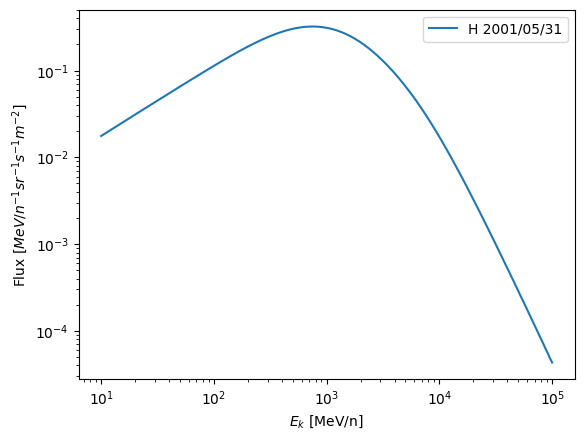

In [5]:
# plot
fig, ax = plt.subplots()
ax.plot(
    df["Ekn[MeV/n]"],
    df["J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]"],
    label=f"H {dt.datetime.fromtimestamp(t, dt.UTC).strftime('%Y/%m/%d')}",
)
ax.set_xlabel(r"$E_{k}$ [MeV/n]")
# log scale
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(r"Flux $[MeV/n^{-1} sr^{-1} s^{-1} m^{-2}]$")
ax.legend()
plt.show()